# Coastal Water Quality: Phase 3 Relative Water-Quality Maps

> Terms are defined in [`GLOSSARY.md`](./GLOSSARY.md). Phase 2 is [`02_spectral_exploration.ipynb`](./02_spectral_exploration.ipynb).

**Scene:** `20250302_030003_92_4001`, Borneo and the Makassar Strait coast.

## Objective
Phase 2 showed that the spectral features are present. This notebook maps turbidity, chlorophyll, and CDOM to show where each signal occurs between the river mouth and the sea.

## Important caveat

These maps are **relative**, not calibrated. They show how pixels rank against one another, such as higher turbidity at the river mouth and lower turbidity offshore. The colourbar values are internal indices, not FNU for turbidity or mg·m⁻³ for chlorophyll.

Real units require field measurements from the same place and day. Those measurements would link an index value to a physical concentration. They are not available here. Published algorithms include a physical equation form and coefficients calibrated for particular sensors and water bodies. This notebook uses the equation forms but not coefficients from a different sensor or site, because that would create misleading absolute values.

This is deliberate. The analysis asks what signal the scene contains and where it occurs. Relative indices answer that question without presenting uncalibrated values as measurements.

## This notebook
1. Rebuilds the Phase 2 water mask so calculations use only clean water.
2. Maps the turbidity signal from the river sediment plume.
3. Maps NDCI and checks whether a chlorophyll signal is present.
4. Maps the CDOM ratio and assesses sediment confounding.
5. Measures cross-talk between the three indices.
6. Plots a river-to-offshore transect.


## 0. Setup, bands, and water mask

The notebook follows the memory-safe `h5py` approach from Phase 2. It reads only the 443, 490, 560, 665, 708, and 861 nm bands and the cube mask layers. It then rebuilds the same sequence: valid pixels, clean pixels with no cloud or cirrus, and water pixels with `NDWI > 0`. Every product is calculated only over this water mask.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import h5py
import rasterio

def find_root(start=Path.cwd()):
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "data" / "inventory").exists():
            return cand
    return p

PROJECT_ROOT = find_root()
SCENE_ID = "20250302_030003_92_4001"
DATA_DIR = PROJECT_ROOT / "data" / "coastal" / SCENE_ID
FIG_DIR  = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
SR_PATH  = DATA_DIR / "ortho_sr_hdf5.h5"
RGB_PATH = DATA_DIR / "ortho_visual.tif"
DF, FILL = "HDFEOS/GRIDS/HYP/Data Fields", -9999.0
assert SR_PATH.exists(), f"Missing {SR_PATH} - run: python scripts/download_coastal.py --hdf5"

with h5py.File(SR_PATH, "r") as f:
    SR = f[f"{DF}/surface_reflectance"]; WL = np.asarray(SR.attrs["wavelengths"], float)
    def band(nm):
        i = int(np.argmin(np.abs(WL - nm))); b = SR[i].astype("float32"); b[b == FILL] = np.nan
        return b
    b443, b490, b560, b665, b708, b861 = (band(x) for x in (443, 490, 560, 665, 708, 861))
    nodata = f[f"{DF}/nodata_pixels"][:]; cloud = f[f"{DF}/beta_cloud_mask"][:]; cirrus = f[f"{DF}/beta_cirrus_mask"][:]

valid = (nodata == 0) & np.isfinite(b560) & np.isfinite(b861)
clean = valid & (cloud == 0) & (cirrus == 0)
ndwi  = (b560 - b861) / (b560 + b861)
water = clean & (ndwi > 0)
def wonly(a): return np.where(water, a, np.nan)   # keep water pixels, blank the rest

with rasterio.open(RGB_PATH) as ds:
    rgb = np.dstack([ds.read(i) for i in (1, 2, 3)]).astype("float32")
rgb_disp = np.clip(rgb / np.percentile(rgb[rgb > 0], 98), 0, 1)

print(f"water pixels: {int(water.sum()):,}")


water pixels: 208,741


## 1. Turbidity: the sediment plume

Suspended sediment scatters light, especially in the red, so red reflectance tracks turbidity. The notebook uses the standard single-band form:

  T = A · ρ(665) / (1 − ρ(665)/C)

The term `1 / (1 − ρ/C)` increases the scale at high reflectance. The saturation constant **C is an illustrative value near 0.25**, just above the brightest water pixel, so the equation remains defined. The scale factor **A is unset**, so this is a relative turbidity index, not FNU.

Look for high values at the Sangatta river mouth and a gradual decrease offshore as the plume disperses.


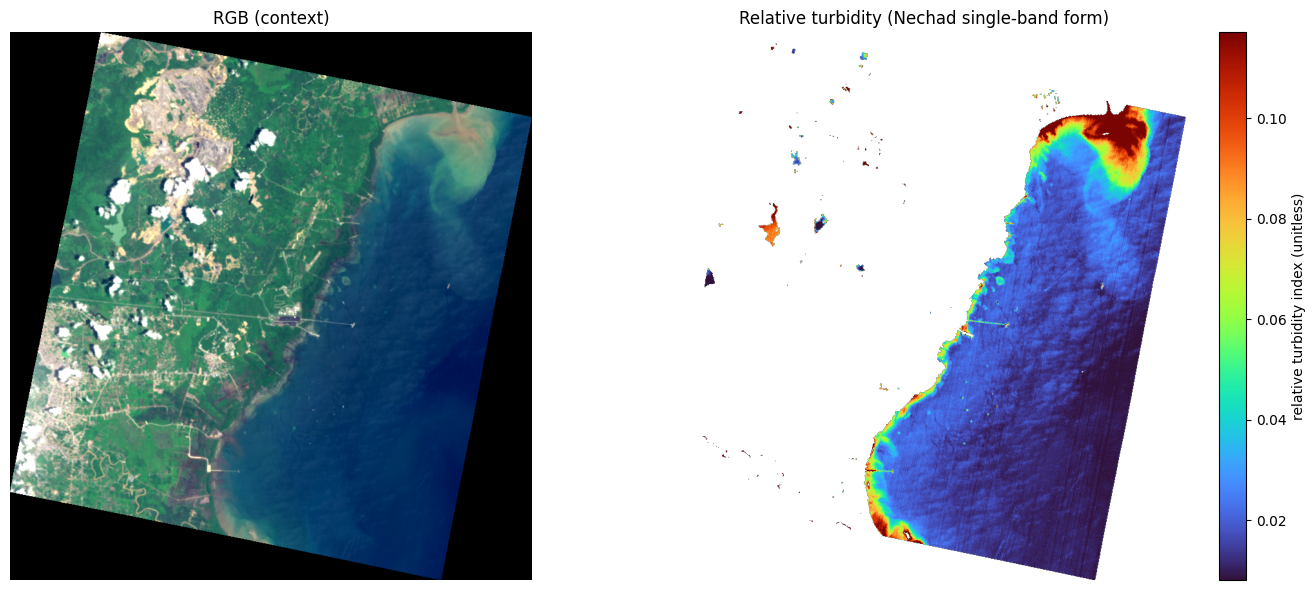

saved -> data/Coastal/figures/03_turbidity.png


In [2]:
C_SAT = 0.25                         # illustrative saturation reflectance, > brightest water (NOT a calibration)
turbidity = wonly(b665 / (1.0 - b665 / C_SAT))

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(rgb_disp); ax[0].set_title("RGB (context)"); ax[0].axis("off")
im = ax[1].imshow(turbidity, cmap="turbo",
                  vmin=np.nanpercentile(turbidity, 2), vmax=np.nanpercentile(turbidity, 98))
ax[1].set_title("Relative turbidity (Nechad single-band form)"); ax[1].axis("off")
fig.colorbar(im, ax=ax[1], fraction=0.046, label="relative turbidity index (unitless)")
fig.tight_layout(); fig.savefig(FIG_DIR / "03_turbidity.png", dpi=150, bbox_inches="tight")
plt.show(); print("saved ->", FIG_DIR / "03_turbidity.png")


**References used here**
- Nechad, B., Ruddick, K.G., & Park, Y. (2010). *Calibration and validation of a generic multisensor algorithm for mapping of total suspended matter in turbid waters.* Remote Sensing of Environment, 114(4), 854–866. https://doi.org/10.1016/j.rse.2009.11.022. We use the **single-band turbidity/TSM form T = A·ρ/(1 − ρ/C)** as a relative index and do not apply calibrated A, B, or C values.
- Dogliotti, A.I., Ruddick, K.G., Nechad, B., Doxaran, D., & Knaeps, E. (2015). *A single algorithm to retrieve turbidity from remotely-sensed data in all coastal and estuarine waters.* Remote Sensing of Environment, 156, 157–168. https://doi.org/10.1016/j.rse.2014.09.020. This supports use of the red band for low-to-moderate turbidity.


## 2. Chlorophyll: is there a signal?

Chlorophyll-*a* absorbs red light near 665 nm and reflects near the 708 nm red edge. NDCI expresses this contrast:

  NDCI = (ρ(708) − ρ(665)) / (ρ(708) + ρ(665))

Higher NDCI indicates more chlorophyll. The map is relative because NDCI is already normalized.

Phase 2 found negative NDCI over this water, with ρ(708) below ρ(665). The map should therefore be negative almost everywhere. Any weak structure is likely sediment-related rather than evidence of a chlorophyll bloom.


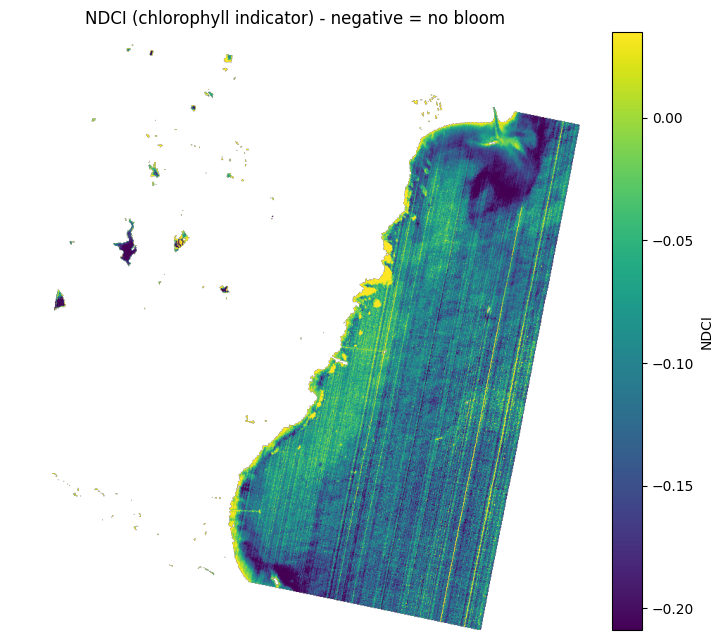

NDCI over water: median=-0.106, fraction positive=1.1%
saved -> data/Coastal/figures/03_chlorophyll.png


In [3]:
ndci = wonly((b708 - b665) / (b708 + b665))

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(ndci, cmap="viridis", vmin=np.nanpercentile(ndci, 2), vmax=np.nanpercentile(ndci, 98))
ax.set_title("NDCI (chlorophyll indicator) - negative = no bloom"); ax.axis("off")
fig.colorbar(im, ax=ax, fraction=0.046, label="NDCI")
fig.tight_layout(); fig.savefig(FIG_DIR / "03_chlorophyll.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"NDCI over water: median={np.nanmedian(ndci):.3f}, "
      f"fraction positive={100*np.nanmean(ndci > 0):.1f}%")
print("saved ->", FIG_DIR / "03_chlorophyll.png")


**References used here**
- Mishra, S., & Mishra, D.R. (2012). *Normalized difference chlorophyll index: A novel model for remote estimation of chlorophyll-a concentration in turbid productive waters.* Remote Sensing of Environment, 117, 394–406. https://doi.org/10.1016/j.rse.2011.10.016. We map **NDCI = (ρ₇₀₈ − ρ₆₆₅)/(ρ₇₀₈ + ρ₆₆₅)** and do not apply the paper's lake-specific NDCI-to-chlorophyll regression, because negative NDCI would give meaningless absolute values.


## 3. CDOM: the least certain product

CDOM, coloured dissolved organic matter, absorbs most strongly in the blue and less in the green. Higher CDOM lowers blue reflectance relative to green, so the ratio **ρ(560)/ρ(443)** rises. The notebook uses this as a relative CDOM index.

Sediment also changes blue and green reflectance. In this Case-2 scene, the CDOM ratio can therefore follow turbidity instead of independent CDOM. Section 4 measures that cross-talk. Treat this as the least certain of the three products.


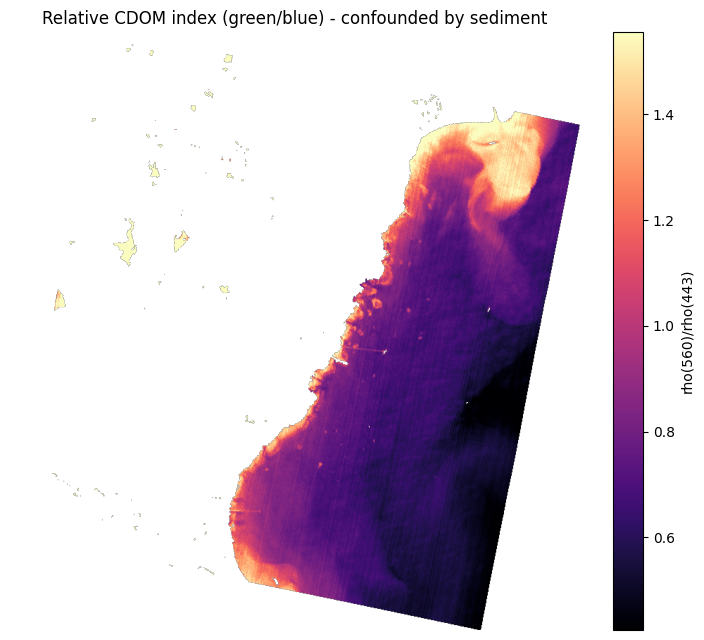

saved -> data/Coastal/figures/03_cdom.png


In [4]:
cdom = wonly(b560 / b443)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(cdom, cmap="magma", vmin=np.nanpercentile(cdom, 2), vmax=np.nanpercentile(cdom, 98))
ax.set_title("Relative CDOM index (green/blue) - confounded by sediment"); ax.axis("off")
fig.colorbar(im, ax=ax, fraction=0.046, label="rho(560)/rho(443)")
fig.tight_layout(); fig.savefig(FIG_DIR / "03_cdom.png", dpi=150, bbox_inches="tight")
plt.show(); print("saved ->", FIG_DIR / "03_cdom.png")


**References used here**
- Bricaud, A., Morel, A., & Prieur, L. (1981). *Absorption by dissolved organic matter of the sea (yellow substance) in the UV and visible domains.* Limnology and Oceanography, 26(1), 43–53. https://doi.org/10.4319/lo.1981.26.1.0043. CDOM absorption rises steeply toward the blue, which makes a blue-to-green contrast informative.
- Kutser, T., Pierson, D.C., Kallio, K.Y., Reinart, A., & Sobek, S. (2005). *Mapping lake CDOM by satellite remote sensing.* Remote Sensing of Environment, 94(4), 535–540. https://doi.org/10.1016/j.rse.2004.11.009. This supports estimating CDOM with a visible band ratio, here green over blue.


## 4. Cross-talk: can the signals be separated?

In Case-2 water, turbidity, chlorophyll, and CDOM all affect visible wavelengths. Their indices can partly measure the same process. The notebook correlates the three maps pixel by pixel over water. A high turbidity-to-CDOM correlation indicates that the CDOM ratio is mostly re-reading sediment. A near-zero turbidity-to-NDCI correlation supports the conclusion that chlorophyll is not tracking sediment.


Spearman(turbidity, CDOM) = +0.92   Spearman(turbidity, NDCI) = +0.04


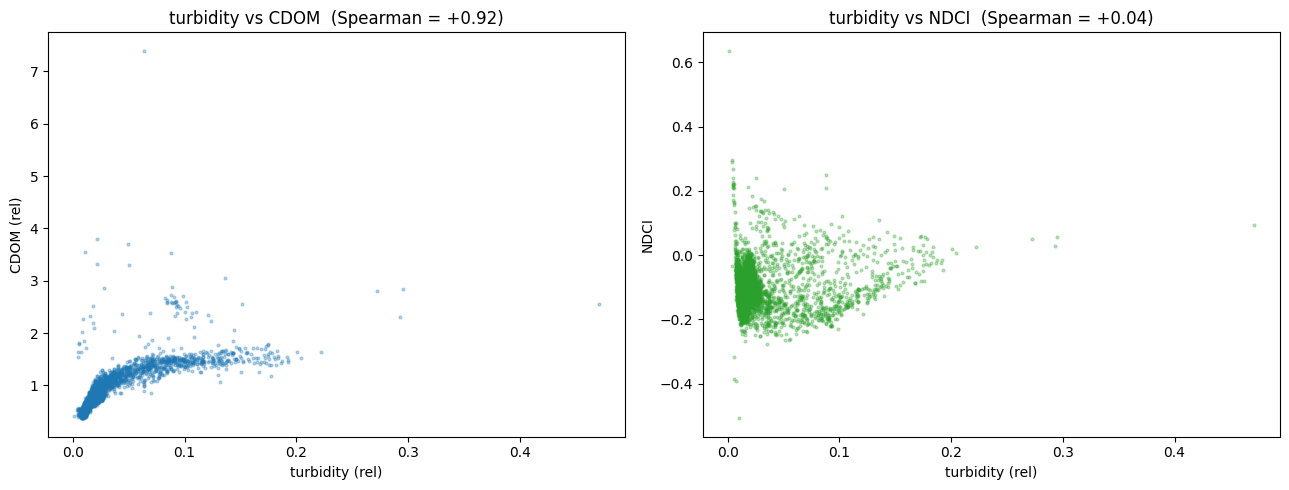

saved -> data/Coastal/figures/03_crosstalk.png


In [5]:
from scipy.stats import spearmanr
m = np.isfinite(turbidity) & np.isfinite(ndci) & np.isfinite(cdom)
t, n_, c = turbidity[m], ndci[m], cdom[m]
# Spearman (rank) correlation: robust to outliers and invariant to the turbidity form's C.
r_tc = spearmanr(t, c).statistic
r_tn = spearmanr(t, n_).statistic
print(f"Spearman(turbidity, CDOM) = {r_tc:+.2f}   Spearman(turbidity, NDCI) = {r_tn:+.2f}")

rng = np.random.default_rng(0)
idx = rng.choice(t.size, size=min(6000, t.size), replace=False)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(t[idx], c[idx], s=4, alpha=0.3); ax[0].set_xlabel("turbidity (rel)"); ax[0].set_ylabel("CDOM (rel)")
ax[0].set_title(f"turbidity vs CDOM  (Spearman = {r_tc:+.2f})")
ax[1].scatter(t[idx], n_[idx], s=4, alpha=0.3, color="C2"); ax[1].set_xlabel("turbidity (rel)"); ax[1].set_ylabel("NDCI")
ax[1].set_title(f"turbidity vs NDCI  (Spearman = {r_tn:+.2f})")
fig.tight_layout(); fig.savefig(FIG_DIR / "03_crosstalk.png", dpi=150, bbox_inches="tight")
plt.show(); print("saved ->", FIG_DIR / "03_crosstalk.png")


## 5. River-to-offshore transect

A transect shows the gradient along one line from the turbid river mouth to clear offshore water. The notebook reads all three indices along this line and rescales each from 0 to 1 for a shared axis. Turbidity should begin high near the coast and decline offshore. CDOM falling with turbidity would show cross-talk. NDCI should have no coherent trend because this scene does not show a meaningful chlorophyll signal. Its rescaled variation is noise, not a strong result.


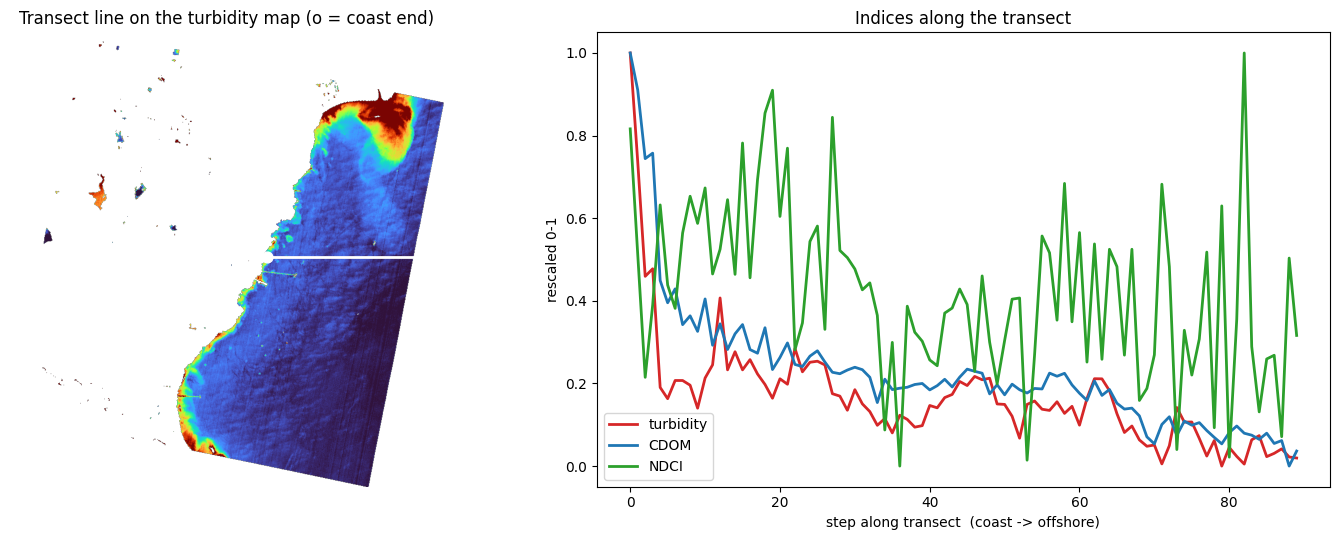

saved -> data/Coastal/figures/03_transect.png


In [6]:
start, end = (420, 480), (420, 780)          # west (coast) -> east (offshore), row 420
N = 100
rows = np.linspace(start[0], end[0], N).round().astype(int)
cols = np.linspace(start[1], end[1], N).round().astype(int)
def along(a): return a[rows, cols]
def norm(a):
    a = a.astype("float32"); lo, hi = np.nanmin(a), np.nanmax(a); return (a - lo) / (hi - lo + 1e-9)

t_prof, n_prof, c_prof = along(turbidity), along(ndci), along(cdom)
step = np.arange(N)

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
ax[0].imshow(turbidity, cmap="turbo", vmin=np.nanpercentile(turbidity, 2), vmax=np.nanpercentile(turbidity, 98))
ax[0].plot(cols, rows, "w-", lw=2); ax[0].scatter([cols[0]], [rows[0]], c="white", s=60, marker="o")
ax[0].set_title("Transect line on the turbidity map (o = coast end)"); ax[0].axis("off")
ax[1].plot(step, norm(t_prof), "C3", lw=2, label="turbidity")
ax[1].plot(step, norm(c_prof), "C0", lw=2, label="CDOM")
ax[1].plot(step, norm(n_prof), "C2", lw=2, label="NDCI")
ax[1].set_xlabel("step along transect  (coast -> offshore)"); ax[1].set_ylabel("rescaled 0-1")
ax[1].set_title("Indices along the transect"); ax[1].legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "03_transect.png", dpi=150, bbox_inches="tight")
plt.show(); print("saved ->", FIG_DIR / "03_transect.png")


## Summary and hand-off to Phase 7

**Phase 3 produced relative, uncalibrated maps**
- **Turbidity:** a clear sediment plume starts at the river mouth and fades offshore. This is the strongest product.
- **Chlorophyll (NDCI):** values are negative almost everywhere, so there is no meaningful chlorophyll signal. The scene is driven by sediment rather than algae.
- **CDOM (green/blue):** the pattern is strongly confounded by sediment. Its Spearman correlation with turbidity is about 0.9, so it largely re-reads the plume rather than independent CDOM.
- **Transect:** the smooth offshore decline supports a dispersing river plume.

**Figures:** `03_turbidity.png`, `03_chlorophyll.png`, `03_cdom.png`, `03_crosstalk.png`, `03_transect.png`.

**Conclusion:** The scene supports a relative turbidity or sediment result. Chlorophyll and CDOM are weak or confounded. **Next:** [`07_uncertainty.ipynb`](./07_uncertainty.ipynb) tests sensitivity to the masks, saturation constant C, glint and adjacency near the coast, and the lack of in-situ calibration.
